# This file contains Processes Exercises of Lecture 4

This exercise was done on data of the Moselle.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from cartopy.io import shapereader
from rich import print
import matplotlib.pyplot as plt
import xarray as xr
import shutil

In [9]:
own_region = 'Rhine'  # for example: "Rhine"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to save forcing results
saveLocation = forcing_path / f"{own_region}_2010_2011_Forcing"

In [10]:
# Period of interest
experiment_start_time = "2010-10-01T00:00:00Z"
experiment_end_time = "2011-09-30T00:00:00Z"

In [11]:
# # ERA5 data Rhine
# ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#     dataset="ERA5",
#     start_time=experiment_start_time,
#     end_time=experiment_end_time,
#     shape=shapeFile.absolute(),
# )

In [12]:
# shutil.copytree(ERA5_forcing.directory, saveLocation)

In [14]:
# Name of shapefile/region
own_region = "Rhine"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_2010_2011_Forcing"

# Load ERA5 data
ERA5_forcing_Rhine = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

FileNotFoundError: Forcing file /home/group10/teaching-materials/book/exercise_journal_ann_laura/Exercises/Forcing/Rhine_2010_2011_Forcing/ewatercycle_forcing.yaml not found. Perhaps you want to use LumpedMakkinkForcing(...)?

In [8]:
temp = ERA5_forcing_Rhine.to_xarray()["tas"]
prec = ERA5_forcing_Rhine.to_xarray()["pr"]
temp

<xarray.DataArray 'tas' (time: 730)> Size: 3kB
dask.array<open_dataset-tas, shape=(730,), dtype=float32, chunksize=(730,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 2010-01-01T12:00:00 ... 2011-12-31T12:...
    lat      float64 8B 49.25
    lon      float64 8B 8.0
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    cell_methods:   day_of_year: year: mean latitude: longitude: mean
    height:         2.0
    height_units:   m

In [9]:
prec = prec * 86400
temp = temp - 272.15

In [10]:
temp["time"] = temp["time"].dt.date
prec["time"] = prec["time"].dt.date

In [11]:
temp.name = "T C" 
prec.name = "P mm/d"

df = xr.merge([temp, prec]).to_dataframe()
Rhine = df[["T C", "P mm/d"]].dropna()
Rhine.index = pd.to_datetime(Rhine.index)
Rhine = Rhine.loc["2010-10-01":"2011-09-30"]
Rhine

,T C,P mm/d
time,,
2010-10-01,11.667267,2.752010
2010-10-02,13.232605,4.104309
2010-10-03,16.067474,0.328541
2010-10-04,15.375946,1.404910
2010-10-05,14.587494,3.714087
...,...,...
2011-09-26,17.224243,0.064823
2011-09-27,17.611511,0.177256
2011-09-28,17.545868,0.016370


In [12]:
# Test with exercise data

data = pd.read_excel('Snow1.xlsx', skiprows=(0, 1, 3), usecols=[0, 1, 2, 3, 4], index_col=[0], parse_dates=True)
data['P mm/d'] = data['Precipitation']
data['T C'] = data['Temperature TR']

## Case 1: Flat terrain

In [13]:
Tt = -0.5
Fm = 3
Er = 360 # average elevation Rhine area
dt = 1

def snow_melt(df, Tt, Fm, dt):
    t = np.arange(len(df['P mm/d']))
    Pr = np.zeros(len(t))
    Ps = np.zeros(len(t))
    M = np.zeros(len(t))
    Ssnow = np.zeros(len(t))
    Pl = np.zeros(len(t))

    for i in np.arange(1, len(t)):
        if df['T C'][i] <= Tt:
            Pr[i] = 0
            Ps[i] = df['P mm/d'][i]
            M[i] = 0
            Ssnow[i] = Ssnow[i - 1] + Ps[i] * dt
            Pl[i] = 0

        else:
            Pr[i] = df['P mm/d'][i]
            Ps[i] = 0
            M[i] = np.minimum(Ssnow[i-1] / dt, Fm * (df['T C'][i] - Tt))
            Ssnow[i] = Ssnow[i - 1] - M[i] * dt
            Pl[i] = Pr[i] + M[i]
    
    return t, Pr, Ps, M, Ssnow, Pl

In [14]:
t, Pr, Ps, M, Ssnow, Pl = snow_melt(Rhine, Tt, Fm, dt)

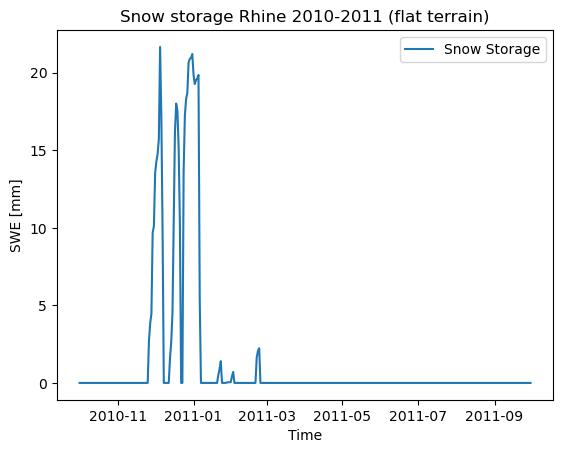

In [15]:
plt.plot(Rhine.index, Ssnow, label="Snow Storage")
plt.title('Snow storage Rhine 2010-2011 (flat terrain)')
plt.xlabel('Time')
plt.ylabel('SWE [mm]')
plt.legend()

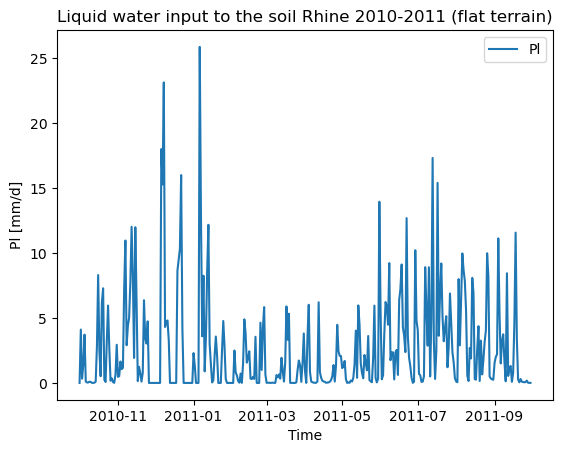

In [16]:
plt.plot(Rhine.index, Pl, label='Pl')
plt.title('Liquid water input to the soil Rhine 2010-2011 (flat terrain)')
plt.xlabel('Time')
plt.ylabel('Pl [mm/d]')
plt.legend()

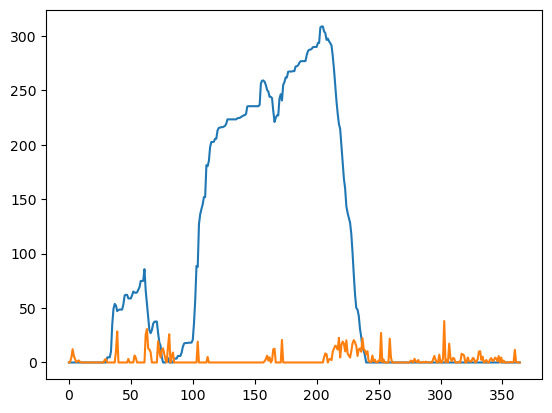

In [17]:
# Test with exercise data
t, Pr, Ps, M, Ssnow, Pl = snow_melt(data, Tt, Fm, dt)

plt.plot(t, Ssnow)
plt.plot(t, Pl)

## Case 2: Different elevation bands

In [18]:
shapeObject = shapereader.Reader(shapeFile.absolute())
record = next(shapeObject.records())
shape_area = record.attributes["SUB_AREA"] * 1e6
print("The catchment area is:", shape_area)

The catchment area is: 163122500000.0

In [19]:
# Rough estimation elevation bands Rhine catchment
E1 = 250
E2 = 750
E3 = 1250
E4 = 1750

A1 = 0.25 * shape_area
A2 = 0.25 * shape_area
A3 = 0.25 * shape_area
A4 = 0.25 * shape_area

In [20]:
def snow_melt(df, Tt, Fm, dt, Ei, Er):
    Ti = df['T C'] - 0.6 * (Ei - Er) / 100
    t = np.arange(len(df['P mm/d']))
    Pr = np.zeros(len(t))
    Ps = np.zeros(len(t))
    M = np.zeros(len(t))
    Ssnow = np.zeros(len(t))
    Pl = np.zeros(len(t))

    for i in np.arange(1, len(t)):
        if Ti[i] <= Tt:
            Pr[i] = 0
            Ps[i] = df['P mm/d'][i]
            M[i] = 0
            Ssnow[i] = Ssnow[i - 1] + Ps[i] * dt
            Pl[i] = 0

        else:
            Pr[i] = df['P mm/d'][i]
            Ps[i] = 0
            M[i] = np.minimum(Ssnow[i-1] / dt, Fm * (Ti[i] - Tt))
            Ssnow[i] = Ssnow[i - 1] - M[i] * dt
            Pl[i] = Pr[i] + M[i]

        # print(df['T C'][i], Ei, Er, Ti[i], Pr[i], Ps[i], M[i], Ssnow[i])
    
    return t, Pr, Ps, M, Ssnow, Pl

In [21]:
_, _, _, _, Ssnow1, Pl1 = snow_melt(Rhine, Tt, Fm, dt, E1, Er)
_, _, _, _, Ssnow2, Pl2 = snow_melt(Rhine, Tt, Fm, dt, E2, Er)
_, _, _, _, Ssnow3, Pl3 = snow_melt(Rhine, Tt, Fm, dt, E3, Er)
_, _, _, _, Ssnow4, Pl4 = snow_melt(Rhine, Tt, Fm, dt, E4, Er)

In [22]:
A_tot = shape_area
Pl_tot = A1 / A_tot * Pl1 + A2 / A_tot * Pl2 + A3 / A_tot * Pl3 + A4 / A_tot * Pl4
Ssnow_tot = A1 / A_tot * Ssnow1 + A2 / A_tot * Ssnow2 + A3 / A_tot * Ssnow3 + A4 / A_tot * Ssnow4

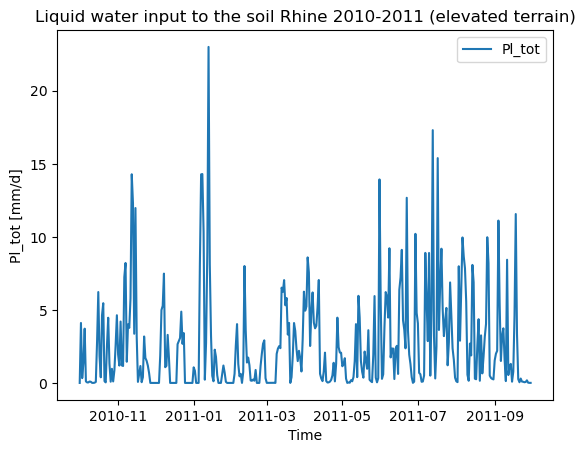

In [23]:
plt.plot(Rhine.index, Pl_tot, label='Pl_tot')
plt.title('Liquid water input to the soil Rhine 2010-2011 (elevated terrain)')
plt.xlabel('Time')
plt.ylabel('Pl_tot [mm/d]')
plt.legend()

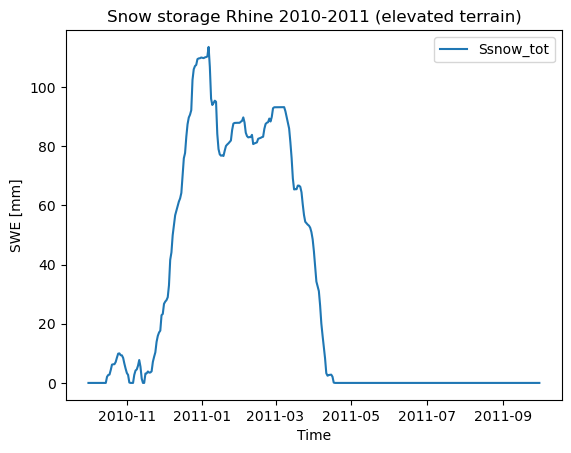

In [24]:
plt.plot(Rhine.index, Ssnow_tot, label='Ssnow_tot')
plt.title('Snow storage Rhine 2010-2011 (elevated terrain)')
plt.xlabel('Time')
plt.ylabel('SWE [mm]')
plt.legend()

## Case 3: Increase in temp [2 degrees C]

In [25]:
Rhine['T+2 C'] = Rhine['T C'] + 2

In [26]:
def snow_melt(df, Tt, Fm, dt, Ei, Er):
    Ti = df['T+2 C'] - 0.6 * (Ei - Er) / 100
    t = np.arange(len(df['P mm/d']))
    Pr = np.zeros(len(t))
    Ps = np.zeros(len(t))
    M = np.zeros(len(t))
    Ssnow = np.zeros(len(t))
    Pl = np.zeros(len(t))

    for i in np.arange(1, len(t)):
        if Ti[i] <= Tt:
            Pr[i] = 0
            Ps[i] = df['P mm/d'][i]
            M[i] = 0
            Ssnow[i] = Ssnow[i - 1] + Ps[i] * dt
            Pl[i] = 0

        else:
            Pr[i] = df['P mm/d'][i]
            Ps[i] = 0
            M[i] = np.minimum(Ssnow[i-1] / dt, Fm * (Ti[i] - Tt))
            Ssnow[i] = Ssnow[i - 1] - M[i] * dt
            Pl[i] = Pr[i] + M[i]

        # print(df['T C'][i], Ei, Er, Ti[i], Pr[i], Ps[i], M[i], Ssnow[i])
    
    return t, Pr, Ps, M, Ssnow, Pl

In [27]:
_, _, _, _, Ssnow31, Pl31 = snow_melt(Rhine, Tt, Fm, dt, E1, Er)
_, _, _, _, Ssnow32, Pl32 = snow_melt(Rhine, Tt, Fm, dt, E2, Er)
_, _, _, _, Ssnow33, Pl33 = snow_melt(Rhine, Tt, Fm, dt, E3, Er)
_, _, _, _, Ssnow34, Pl34 = snow_melt(Rhine, Tt, Fm, dt, E4, Er)

In [28]:
Pl_tot3 = A1 / A_tot * Pl31 + A2 / A_tot * Pl32 + A3 / A_tot * Pl33 + A4 / A_tot * Pl34
Ssnow_tot3 = A1 / A_tot * Ssnow31 + A2 / A_tot * Ssnow32 + A3 / A_tot * Ssnow33 + A4 / A_tot * Ssnow34

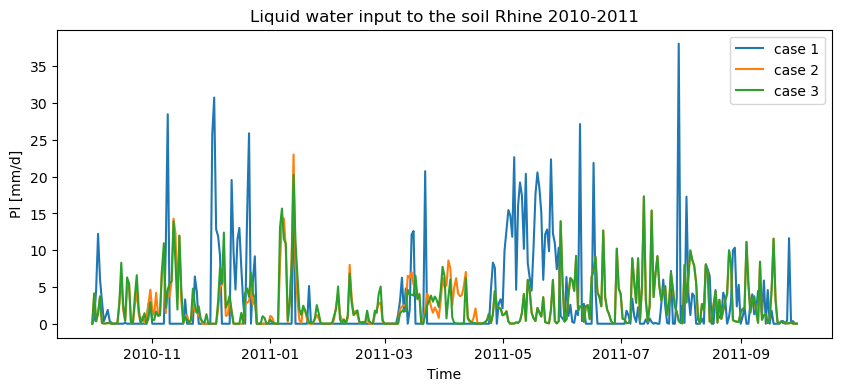

In [29]:
plt.figure(figsize=(10, 4))

plt.plot(Rhine.index, Pl, label='case 1')
plt.plot(Rhine.index, Pl_tot, label='case 2')
plt.plot(Rhine.index, Pl_tot3, label='case 3')
plt.title('Liquid water input to the soil Rhine 2010-2011')
plt.xlabel('Time')
plt.ylabel('Pl [mm/d]')
plt.legend()

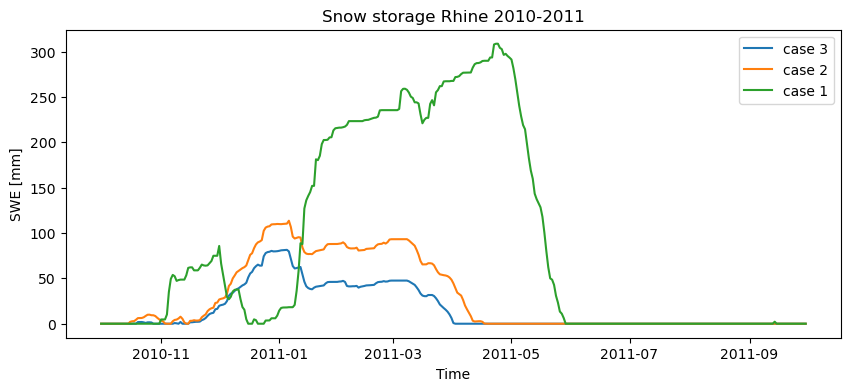

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(Rhine.index, Ssnow_tot3, label='case 3')
plt.plot(Rhine.index, Ssnow_tot, label='case 2')
plt.plot(Rhine.index, Ssnow, label='case 1')

plt.title('Snow storage Rhine 2010-2011')
plt.xlabel('Time')
plt.ylabel('SWE [mm]')
plt.legend()